# 01. EDA — Bank Customer Transactions

Цель: исследовать датасет банковских транзакций и обосновать ключевые решения по очистке, фичам, сплиту и метрике для последующего моделирования.

**Таргет:** `TransactionAmount (INR)` (сумма транзакции в индийских рупиях)

**Метрика выбора финальной модели:** **MAE** (основная), **RMSE** и **R²** (дополнительные). Обоснование — в самом конце ноутбука после анализа распределения таргета.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import SEED
from src.preprocessing import load_raw, clean, TARGET

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
np.random.seed(SEED)

IMG_DIR = PROJECT_ROOT / "report" / "images"
IMG_DIR.mkdir(parents=True, exist_ok=True)

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "bank_transactions.csv"
print("Reading:", RAW_PATH)


Reading: C:\Users\egorm\PycharmProjects\hsemlcourse-classroom-0b8e58-hseml-group-project-project-template\data\raw\bank_transactions.csv


## 1. Загрузка и общий обзор

In [2]:
df_raw = load_raw(RAW_PATH)
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (1048567, 9)


,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0
1,T2,C2142763,1957-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,142712,459.0
3,T4,C5342380,1973-09-14,F,MUMBAI,866503.21,2016-08-02,142714,2060.0
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   TransactionID            1048567 non-null  str           
 1   CustomerID               1048567 non-null  str           
 2   CustomerDOB              987831 non-null   datetime64[us]
 3   CustGender               1047467 non-null  str           
 4   CustLocation             1048416 non-null  str           
 5   CustAccountBalance       1046198 non-null  float64       
 6   TransactionDate          1048567 non-null  datetime64[us]
 7   TransactionTime          1048567 non-null  int64         
 8   TransactionAmount (INR)  1048567 non-null  float64       
dtypes: datetime64[us](2), float64(2), int64(1), str(4)
memory usage: 72.0 MB


In [4]:
print("Пропуски по колонкам:")
df_raw.isna().sum()


Пропуски по колонкам:


TransactionID                  0
CustomerID                     0
CustomerDOB                60736
CustGender                  1100
CustLocation                 151
CustAccountBalance          2369
TransactionDate                0
TransactionTime                0
TransactionAmount (INR)        0
dtype: int64

In [5]:
print("Дубликаты по TransactionID:", df_raw["TransactionID"].duplicated().sum())
print("Дубликаты по всем колонкам:", df_raw.duplicated().sum())


Дубликаты по TransactionID: 0


Дубликаты по всем колонкам: 0


## 2. Целевая переменная — `TransactionAmount (INR)`

Самое важное наблюдение всего EDA: распределение крайне правоскошенное. Это диктует выбор метрики и стратегию обучения (рассмотрение `log1p(target)`).


In [6]:
y = df_raw[TARGET]
print(y.describe(percentiles=[0.5, 0.9, 0.99, 0.999]).round(2))
print("Skew:", round(y.skew(), 2))
print("Нулевых значений:", (y == 0).sum())


count    1048567.00
mean        1574.34
std         6574.74
min            0.00
50%          459.03
90%         2947.06
99%        20000.00
99.9%      95000.00
max      1560034.99
Name: TransactionAmount (INR), dtype: float64
Skew: 47.34
Нулевых значений: 835


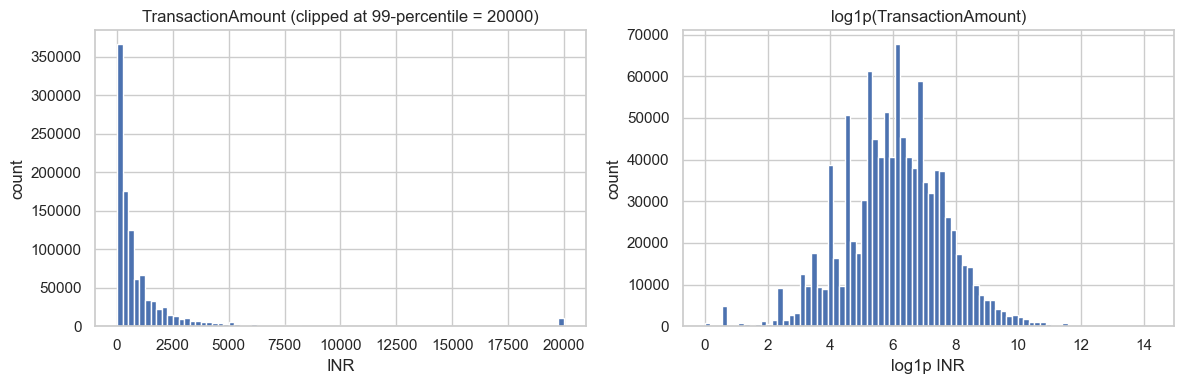

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y.clip(upper=y.quantile(0.99)), bins=80)
axes[0].set_title(f"TransactionAmount (clipped at 99-percentile = {y.quantile(0.99):.0f})")
axes[0].set_xlabel("INR")
axes[0].set_ylabel("count")

axes[1].hist(np.log1p(y), bins=80)
axes[1].set_title("log1p(TransactionAmount)")
axes[1].set_xlabel("log1p INR")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.savefig(IMG_DIR / "target_distribution.png", dpi=120, bbox_inches="tight")
plt.show()


## 3. Очистка и базовая обработка

In [8]:
df = clean(df_raw)
print("После clean(): shape =", df.shape)
print("Удалено строк:", len(df_raw) - len(df))
df.isna().sum()


После clean(): shape = (1047731, 9)
Удалено строк: 836


TransactionID              0
CustomerID                 0
CustomerDOB                0
CustGender                 0
CustLocation               0
CustAccountBalance         0
TransactionDate            0
TransactionTime            0
TransactionAmount (INR)    0
dtype: int64

**Что делает `clean()`:**
- удаляет дубли по `TransactionID`;
- удаляет транзакции с `TransactionAmount == 0` (мешают log-таргету и не несут сигнала);
- оставляет только корректные значения `CustGender` (`M` / `F` / NaN);
- заполняет пропуски: для числовых — медианой, для категориальных — `"unknown"`.


## 4. Демография клиентов

In [9]:
print("Гендер:")
print(df["CustGender"].value_counts(dropna=False))
print("\nТоп-10 локаций:")
print(df["CustLocation"].value_counts().head(10))
print("\nВсего уникальных локаций:", df["CustLocation"].nunique())


Гендер:
CustGender
M          764847
F          281784
unknown      1100
Name: count, dtype: int64

Топ-10 локаций:
CustLocation
MUMBAI       103512
NEW DELHI     84834
BANGALORE     81479
GURGAON       73745
DELHI         70940
NOIDA         32753
CHENNAI       29995
PUNE          25837
HYDERABAD     23017
THANE         21496
Name: count, dtype: int64



Всего уникальных локаций: 9352


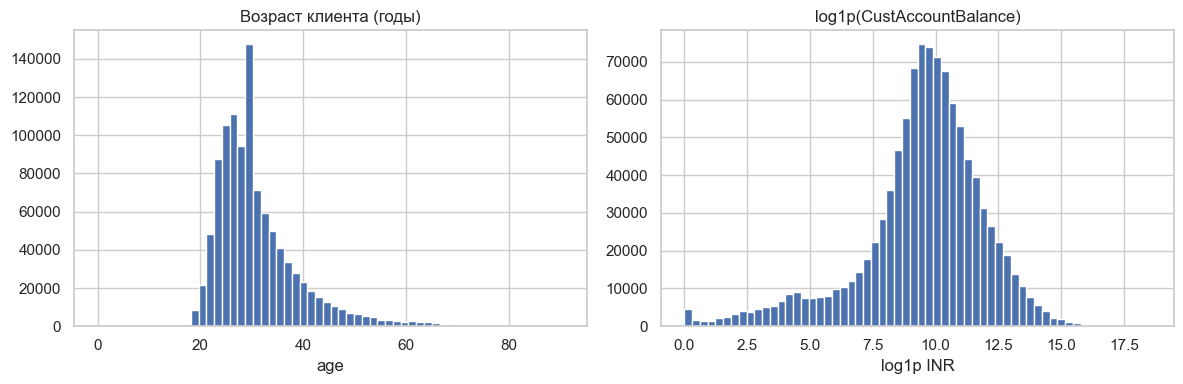

In [10]:
ages = ((df["TransactionDate"] - df["CustomerDOB"]).dt.days / 365.25).clip(0, 110)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(ages.dropna(), bins=60)
ax[0].set_title("Возраст клиента (годы)")
ax[0].set_xlabel("age")

ax[1].hist(np.log1p(df["CustAccountBalance"].clip(lower=0)), bins=60)
ax[1].set_title("log1p(CustAccountBalance)")
ax[1].set_xlabel("log1p INR")

plt.tight_layout()
plt.savefig(IMG_DIR / "demographics.png", dpi=120, bbox_inches="tight")
plt.show()


## 5. Зависимости таргета от признаков

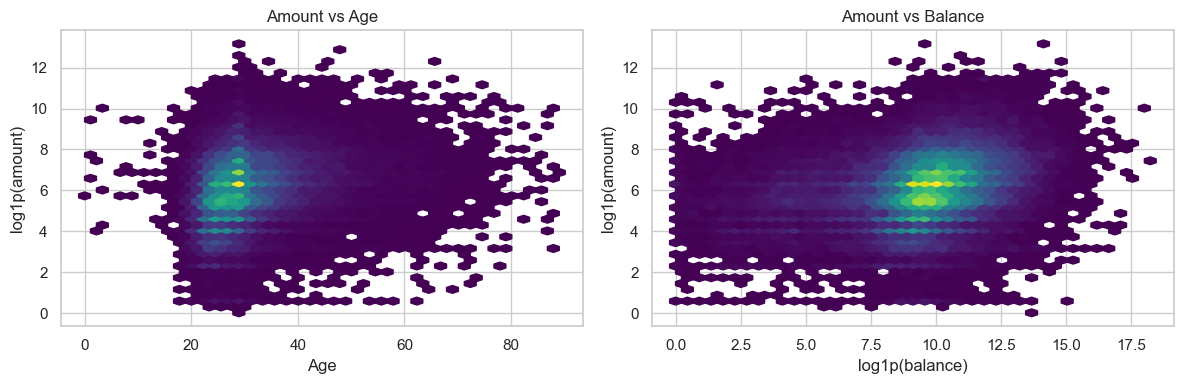

In [11]:
sample = df.sample(min(len(df), 50_000), random_state=SEED).copy()
sample["Age"] = ((sample["TransactionDate"] - sample["CustomerDOB"]).dt.days / 365.25).clip(0, 110)
sample["LogBalance"] = np.log1p(sample["CustAccountBalance"].clip(lower=0))
sample["LogAmount"] = np.log1p(sample[TARGET])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hexbin(sample["Age"], sample["LogAmount"], gridsize=40, mincnt=1, cmap="viridis")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("log1p(amount)")
axes[0].set_title("Amount vs Age")

axes[1].hexbin(sample["LogBalance"], sample["LogAmount"], gridsize=40, mincnt=1, cmap="viridis")
axes[1].set_xlabel("log1p(balance)")
axes[1].set_ylabel("log1p(amount)")
axes[1].set_title("Amount vs Balance")

plt.tight_layout()
plt.savefig(IMG_DIR / "amount_vs_features.png", dpi=120, bbox_inches="tight")
plt.show()


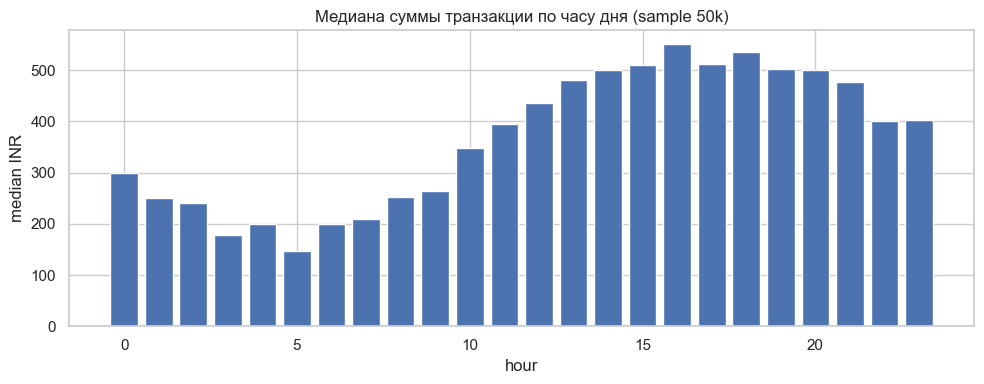

In [12]:
sample["Hour"] = sample["TransactionTime"].astype(int).astype(str).str.zfill(6).str[:2].astype(int).clip(0, 23)
hour_stats = sample.groupby("Hour")[TARGET].agg(["median", "count"])
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hour_stats.index, hour_stats["median"])
ax.set_title("Медиана суммы транзакции по часу дня (sample 50k)")
ax.set_xlabel("hour")
ax.set_ylabel("median INR")
plt.tight_layout()
plt.savefig(IMG_DIR / "amount_by_hour.png", dpi=120, bbox_inches="tight")
plt.show()


In [13]:
gender_stats = sample.groupby("CustGender")[TARGET].agg(["median", "mean", "count"])
print(gender_stats)


            median         mean  count
CustGender                            
F            518.0  1585.327036  13517
M            430.0  1646.104388  36434
unknown      570.0  2428.642041     49


## 6. Корреляции числовых признаков

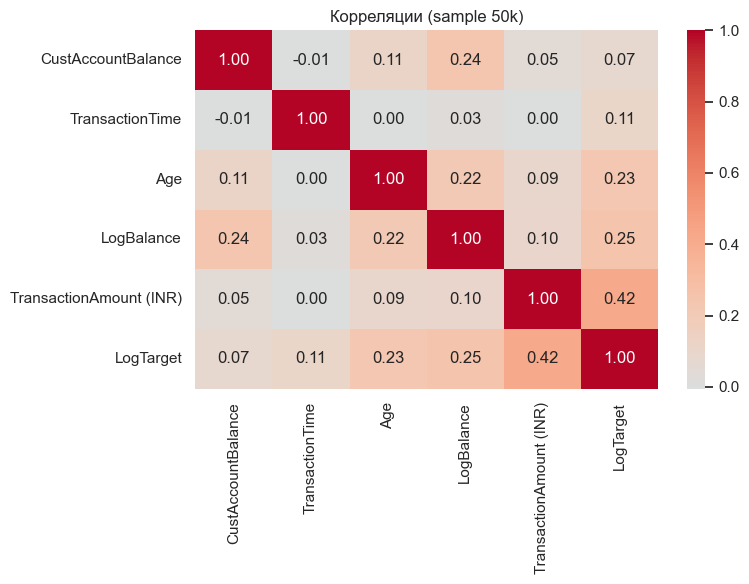

In [14]:
sample["LogTarget"] = np.log1p(sample[TARGET])
corr = sample[["CustAccountBalance", "TransactionTime", "Age", "LogBalance", TARGET, "LogTarget"]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Корреляции (sample 50k)")
plt.tight_layout()
plt.savefig(IMG_DIR / "correlations.png", dpi=120, bbox_inches="tight")
plt.show()


## 7. Временной диапазон транзакций

In [15]:
print("Период транзакций:", df["TransactionDate"].min(), "→", df["TransactionDate"].max())
print("Дней:", (df["TransactionDate"].max() - df["TransactionDate"].min()).days)
print("Уникальных дат:", df["TransactionDate"].nunique())


Период транзакций: 2016-08-01 00:00:00 → 2016-10-21 00:00:00
Дней: 81
Уникальных дат: 55


**Вывод по временному измерению.** Если разброс < ~3 месяцев и очевидной концепт-дрифт-зависимости нет, time-based split не нужен — используем стандартный стратифицированный split по бинам `log1p(target)`.


## 8. Обоснование выбора метрики

| Свойство | Цифра | Что это значит для метрики |
|---|---|---|
| Skew | ~47 (рассчитано выше) | Распределение сильно правоскошенное |
| Медиана | ~459 INR | Большинство транзакций — небольшие |
| Среднее | ~1574 INR | В 3.4× выше медианы — типичный признак тяжёлого хвоста |
| Максимум | ~1.56M INR | Диапазон ~6 порядков |

**Решение.** Основная метрика — **MAE** (Mean Absolute Error):

- Робастна к выбросам в таргете (RMSE будет «съедаться» единичными гигантскими транзакциями).
- В тех же единицах (INR), бизнес-интерпретируема: «в среднем модель ошибается на X рупий».
- Минимизация MAE согласована с предсказанием **медианы** условного распределения, что естественно для скошенных финансовых данных.

**Дополнительно** отслеживаем:

- **RMSE** — чтобы видеть поведение на крупных суммах (где штраф квадратичный).
- **R²** — общая мера доли объяснённой дисперсии для сравнимости моделей.
- **MAPE** — относительная ошибка (вспомогательно, чтобы оценить порядок ошибки на типичной транзакции).

**Альтернатива, которую проверим в `03_experiments.ipynb`:** обучение на `log1p(target)` с обратным преобразованием — это хорошо подходит распределениям, охватывающим несколько порядков.
